# Statistical Analysis: Sex Differences in Rates of Hearing Decline before and after Menopause in Koreans

**Authors:** SungHee Kim et al.  
**Analysis by:** Comprehensive Re-analysis Pipeline  
**Date:** 2026-04-22

---

## Analysis Overview

This notebook implements a full statistical pipeline in 6 phases:

1. **Data Loading & Cleaning** — load, validate, and merge datasets; confirm data integrity for both files
2. **Exploratory Data Analysis (EDA)** — distributions, descriptive statistics, correlation heatmaps
3. **Imbalance Handling** — Propensity Score Matching (PSM) to equalize sex group sizes
4. **Assumption Checking** — normality, homoscedasticity, linearity, outliers
5. **Violation Remedies** — WLS, robust standard errors (HC3), bootstrap BCa confidence intervals, FDR correction
6. **Model Building & Visualization** — ANCOVA, piecewise linear regression, slope comparison, sensitivity analysis

**Data files required** (same folder as this notebook):
- `men.xlsx`
- `women.xlsx`

**Required packages:** `pandas`, `numpy`, `scipy`, `statsmodels`, `sklearn`, `matplotlib`, `seaborn`

Install if needed:
```bash
pip install pandas numpy scipy statsmodels scikit-learn matplotlib seaborn openpyxl
```

---
## Phase 0: Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, levene, bartlett, kstest, norm

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from statsmodels.regression.linear_model import WLS

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
COLORS = {'Men': '#2196F3', 'Women': '#E91E63'}
FREQS  = ['0.25kHz', '0.5kHz', '1kHz', '2kHz', '4kHz', '8kHz']
BREAKPOINT = 49.3      # Korean mean menopause age

print('All packages loaded successfully.')

All packages loaded successfully.


---
## Phase 1: Data Loading & Cleaning

### 1.1 Load raw data

In [2]:
men_raw   = pd.read_excel('men.xlsx')
women_raw = pd.read_excel('women.xlsx')

print(f"Men raw shape   : {men_raw.shape}")
print(f"Women raw shape : {women_raw.shape}")
print()
print('Men columns   :', men_raw.columns.tolist())
print('Women columns :', women_raw.columns.tolist())

Men raw shape   : (910, 8)
Women raw shape : (3175, 8)

Men columns   : ['Sex', 'Age', '0.25kHz', '0.5kHz', '1kHz', '2kHz', '4kHz', '8kHz']
Women columns : ['Sex', 'Age', '0.25kHz', '0.5kHz', '1kHz', '2kHz', '4kHz', '8kHz']


### 1.2 Data validation

> Both `men.xlsx` and `women.xlsx` have been pre-cleaned and share the same column structure:
> `Sex`, `Age`, `0.25kHz`, `0.5kHz`, `1kHz`, `2kHz`, `4kHz`, `8kHz`.
> This cell confirms shapes, column names, dtypes, and checks for any unexpected missing values or duplicates.

In [3]:
def validate_dataset(df, name, expected_cols):
    """Basic integrity checks: shape, columns, dtypes, nulls, duplicates."""
    print(f"=== {name} ===")
    print(f"  Shape     : {df.shape}")
    print(f"  Columns   : {df.columns.tolist()}")
    missing_cols = [c for c in expected_cols if c not in df.columns]
    extra_cols   = [c for c in df.columns if c not in expected_cols]
    if missing_cols:
        print(f"  ⚠ Missing expected columns: {missing_cols}")
    if extra_cols:
        print(f"  ⚠ Unexpected columns: {extra_cols}")
    null_counts = df[expected_cols].isnull().sum()
    if null_counts.any():
        print(f"  Null counts:\n{null_counts[null_counts > 0]}")
    else:
        print(f"  No missing values in expected columns")
    n_dup = df.duplicated().sum()
    print(f"  Duplicate rows: {n_dup}")
    print(f"  Age range : {df['Age'].min():.1f} – {df['Age'].max():.1f} yr")
    print()

EXPECTED_COLS = ['Sex', 'Age'] + FREQS
validate_dataset(men_raw,   "men.xlsx",   EXPECTED_COLS)
validate_dataset(women_raw, "women.xlsx", EXPECTED_COLS)


=== men.xlsx ===
  Shape     : (910, 8)
  Columns   : ['Sex', 'Age', '0.25kHz', '0.5kHz', '1kHz', '2kHz', '4kHz', '8kHz']
  No missing values in expected columns
  Duplicate rows: 0
  Age range : 18.1 – 79.3 yr

=== women.xlsx ===
  Shape     : (3175, 8)
  Columns   : ['Sex', 'Age', '0.25kHz', '0.5kHz', '1kHz', '2kHz', '4kHz', '8kHz']
  No missing values in expected columns
  Duplicate rows: 0
  Age range : 18.7 – 79.8 yr



### 1.3 Standardise column names and merge

In [4]:
def standardise_df(df, sex_label):
    """
    Select and rename columns into a canonical form.
    Both files already have the correct column names,
    so we just select the needed subset and add SexLabel.
    """
    df = df.copy()
    # Strip whitespace from column names (safety)
    df.columns = [str(c).strip() for c in df.columns]
    # Verify all expected frequency columns are present
    missing = [f for f in FREQS if f not in df.columns]
    if missing:
        raise ValueError(f"{sex_label}: Missing frequency columns: {missing}")
    # Add sex label and drop rows missing Age
    df['SexLabel'] = sex_label
    df = df.dropna(subset=['Age'])
    return df[['SexLabel', 'Age'] + FREQS]

men_df   = standardise_df(men_raw,   'Men')
women_df = standardise_df(women_raw, 'Women')

df = pd.concat([men_df, women_df], ignore_index=True)
df['SexCode'] = (df['SexLabel'] == 'Women').astype(int)  # 0=Men, 1=Women
df['AgeGroup'] = np.where(df['Age'] < BREAKPOINT, f'< {BREAKPOINT}', f'≥ {BREAKPOINT}')

print(df.groupby('SexLabel').size().rename('N').to_frame())
print(f'\nTotal: {len(df)} participants')
df.head()


             N
SexLabel      
Men        910
Women     3175

Total: 4085 participants


,SexLabel,Age,0.25kHz,0.5kHz,1kHz,2kHz,4kHz,8kHz,SexCode,AgeGroup
0,Men,18.131507,17.5,12.5,2.5,5.0,2.5,2.5,0,< 49.3
1,Men,18.271233,7.5,7.5,12.5,5.0,12.5,12.5,0,< 49.3
2,Men,18.293151,10.0,7.5,5.0,-2.5,5.0,7.5,0,< 49.3
3,Men,18.410959,12.5,10.0,7.5,5.0,5.0,2.5,0,< 49.3
4,Men,18.452055,12.5,12.5,12.5,12.5,15.0,17.5,0,< 49.3


### 1.4 Basic data quality checks

In [5]:
print('=== Missing values ===')
print(df.isnull().sum())
print()
print('=== Age range by sex ===')
print(df.groupby('SexLabel')['Age'].agg(['min', 'max', 'mean', 'std']).round(2))
print()
print('=== Hearing thresholds (dB HL) — overall ===')
print(df[FREQS].describe().round(2))

=== Missing values ===
SexLabel    0
Age         0
0.25kHz     0
0.5kHz      0
1kHz        0
2kHz        0
4kHz        0
8kHz        0
SexCode     0
AgeGroup    0
dtype: int64

=== Age range by sex ===
            min    max   mean    std
SexLabel                            
Men       18.13  79.30  47.00  10.37
Women     18.71  79.76  44.66  11.20

=== Hearing thresholds (dB HL) — overall ===
       0.25kHz   0.5kHz     1kHz     2kHz     4kHz     8kHz
count  4085.00  4085.00  4085.00  4085.00  4085.00  4085.00
mean     18.60    15.30    13.80    12.72    16.37    22.91
std       7.19     7.26     7.54     8.96    13.11    17.60
min     -10.00   -10.00   -10.00   -10.00   -10.00   -20.00
25%      15.00    10.00    10.00     7.50     7.50    10.00
50%      17.50    15.00    12.50    12.50    12.50    17.50
75%      22.50    20.00    17.50    17.50    20.00    30.00
max      70.00    72.50   100.00   110.00   110.00   110.00


---
## Phase 2: Exploratory Data Analysis (EDA)

### 2.1 Age distribution by sex

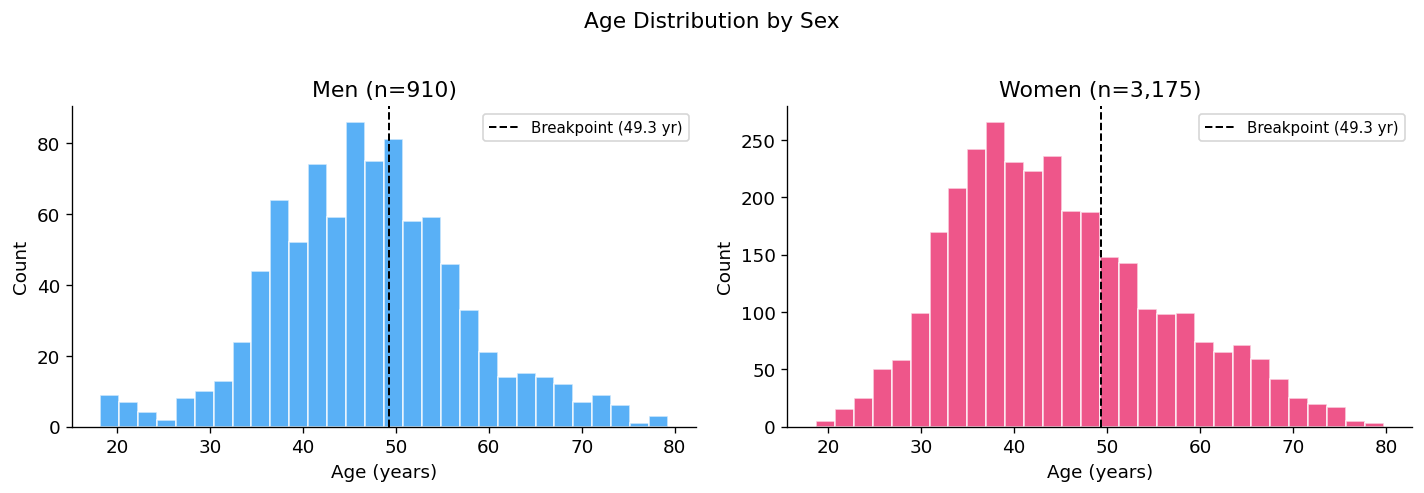

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, sex in zip(axes, ['Men', 'Women']):
    data = df[df['SexLabel'] == sex]['Age']
    ax.hist(data, bins=30, color=COLORS[sex], alpha=0.75, edgecolor='white')
    ax.axvline(BREAKPOINT, color='black', linestyle='--', linewidth=1.2,
               label=f'Breakpoint ({BREAKPOINT} yr)')
    ax.set_title(f'{sex} (n={len(data):,})')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Age Distribution by Sex', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_age_distribution.png', bbox_inches='tight')
plt.show()

### 2.2 Hearing threshold distributions at each frequency

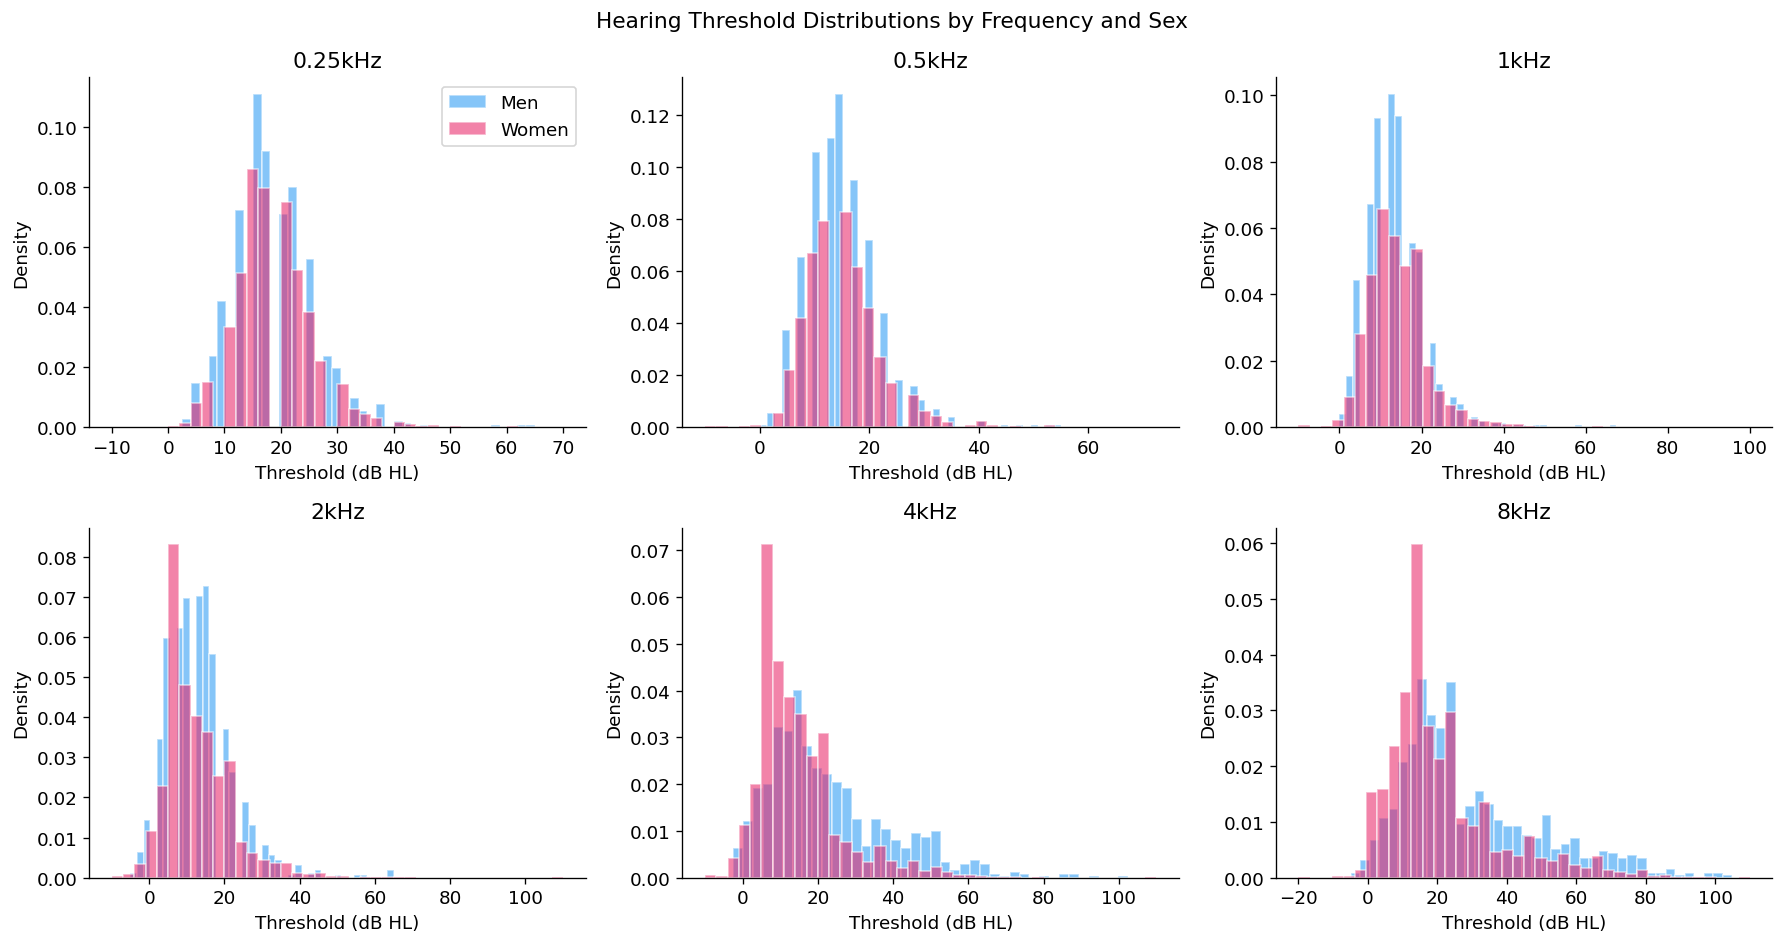

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, freq in zip(axes, FREQS):
    for sex in ['Men', 'Women']:
        data = df[df['SexLabel'] == sex][freq].dropna()
        ax.hist(data, bins=40, alpha=0.55, color=COLORS[sex],
                label=sex, edgecolor='white', density=True)
    ax.set_title(freq)
    ax.set_xlabel('Threshold (dB HL)')
    ax.set_ylabel('Density')

axes[0].legend()
plt.suptitle('Hearing Threshold Distributions by Frequency and Sex', fontsize=13)
plt.tight_layout()
plt.savefig('fig_threshold_distributions.png', bbox_inches='tight')
plt.show()

### 2.3 Descriptive statistics by sex and age group

In [8]:
desc = df.groupby(['SexLabel', 'AgeGroup'])[FREQS].agg(['mean', 'std', 'count'])
desc.columns = ['_'.join(c) for c in desc.columns]
print(desc.round(2))

                   0.25kHz_mean  0.25kHz_std  0.25kHz_count  0.5kHz_mean  \
SexLabel AgeGroup                                                          
Men      < 49.3           16.95         6.24            556        13.86   
         ≥ 49.3           21.02         8.17            354        17.20   
Women    < 49.3           17.00         5.70           2208        13.48   
         ≥ 49.3           22.31         8.62            967        19.57   

                   0.5kHz_std  0.5kHz_count  1kHz_mean  1kHz_std  1kHz_count  \
SexLabel AgeGroup                                                              
Men      < 49.3          5.63           556      12.27      5.83         556   
         ≥ 49.3          7.90           354      16.38      8.15         354   
Women    < 49.3          5.51          2208      11.55      5.53        2208   
         ≥ 49.3          9.17           967      18.86      9.26         967   

                   2kHz_mean  2kHz_std  2kHz_count  4kHz_mean 

### 2.4 Skewness and kurtosis of residuals (pre-modelling)

=== Skewness & Kurtosis of Raw Hearing Thresholds ===
         Skewness  Excess Kurtosis
0.25kHz     1.156            4.528
0.5kHz      1.468            6.079
1kHz        1.655            8.215
2kHz        1.620            6.940
4kHz        1.682            4.084
8kHz        1.432            2.008


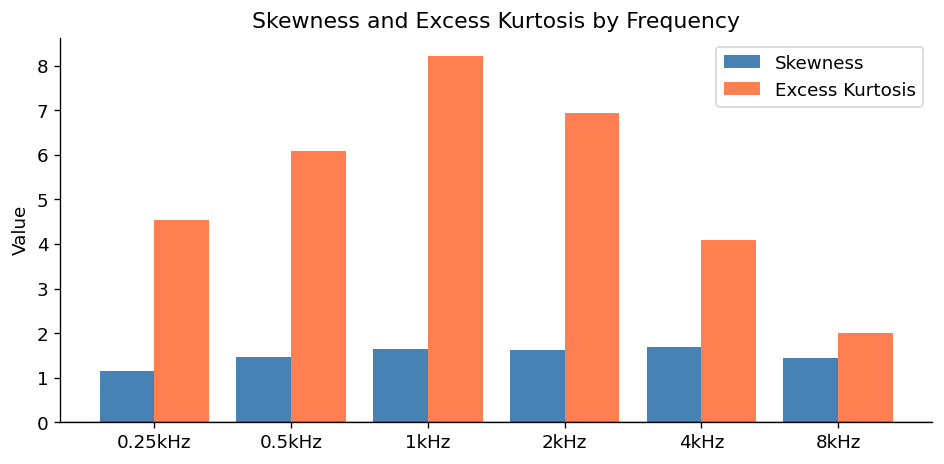

In [9]:
skew_kurt = pd.DataFrame({
    'Skewness': df[FREQS].skew(),
    'Excess Kurtosis': df[FREQS].kurt()
})
print('=== Skewness & Kurtosis of Raw Hearing Thresholds ===')
print(skew_kurt.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(FREQS))
ax.bar(x - 0.2, skew_kurt['Skewness'], 0.4, label='Skewness', color='steelblue')
ax.bar(x + 0.2, skew_kurt['Excess Kurtosis'], 0.4, label='Excess Kurtosis', color='coral')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(FREQS)
ax.set_ylabel('Value')
ax.set_title('Skewness and Excess Kurtosis by Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('fig_skew_kurt.png', bbox_inches='tight')
plt.show()

### 2.5 Correlation heatmap

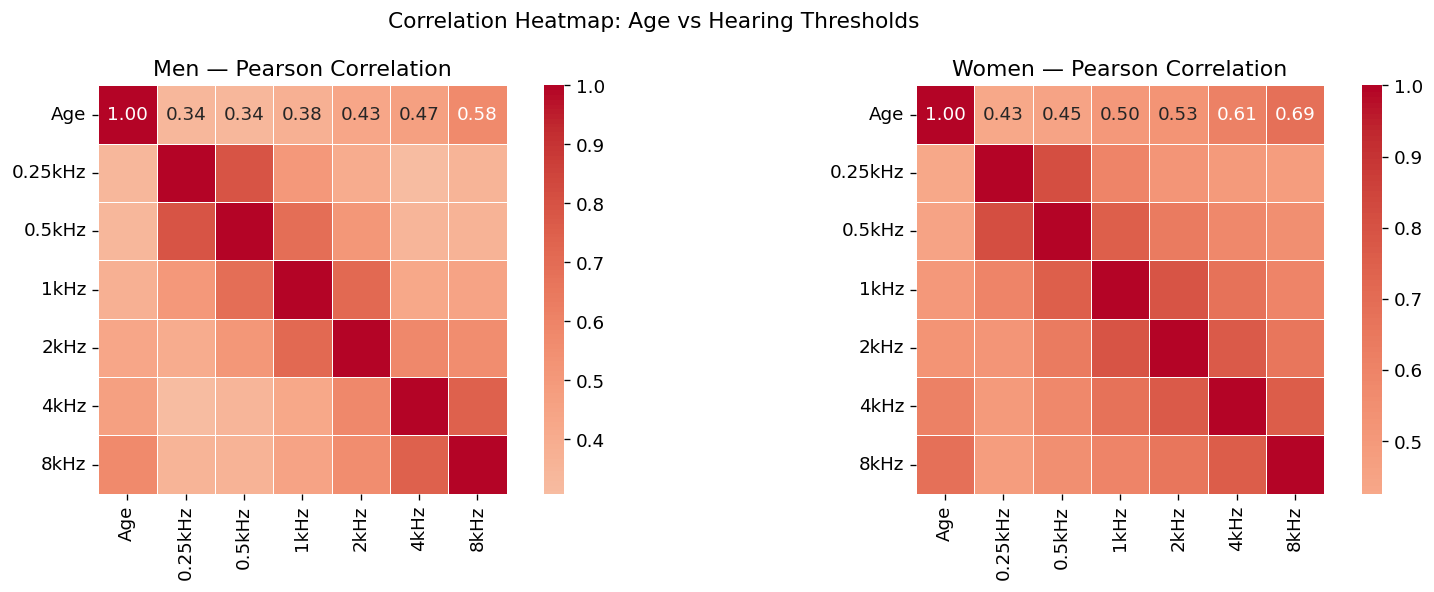

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sex in zip(axes, ['Men', 'Women']):
    corr = df[df['SexLabel'] == sex][['Age'] + FREQS].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, square=True, linewidths=0.5)
    ax.set_title(f'{sex} — Pearson Correlation')

plt.suptitle('Correlation Heatmap: Age vs Hearing Thresholds', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 2.6 Mean hearing threshold by decade-age-group

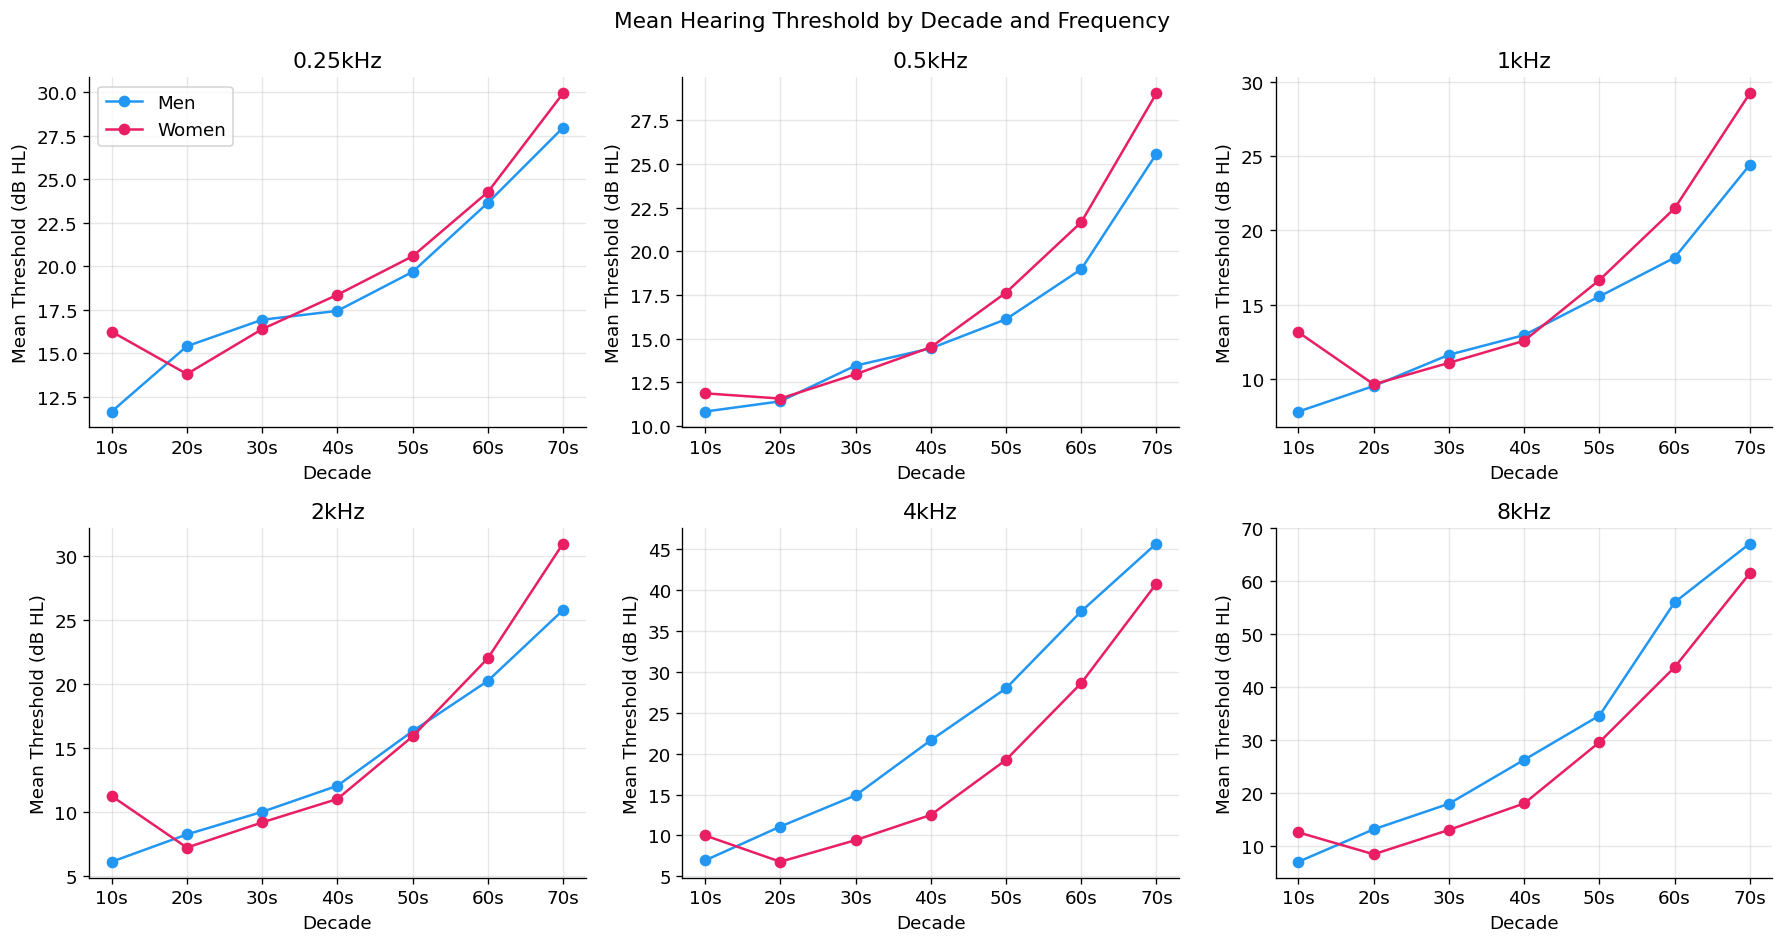

In [11]:
df['Decade'] = (df['Age'] // 10 * 10).astype(int).astype(str) + 's'
decade_mean = df.groupby(['SexLabel', 'Decade'])[FREQS].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, freq in zip(axes, FREQS):
    for sex in ['Men', 'Women']:
        sub = decade_mean.loc[sex][freq]
        ax.plot(sub.index, sub.values, marker='o', color=COLORS[sex], label=sex)
    ax.set_title(freq)
    ax.set_xlabel('Decade')
    ax.set_ylabel('Mean Threshold (dB HL)')
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.suptitle('Mean Hearing Threshold by Decade and Frequency', fontsize=13)
plt.tight_layout()
plt.savefig('fig_threshold_by_decade.png', bbox_inches='tight')
plt.show()

---
## Phase 3: Imbalance Handling — Propensity Score Matching (PSM)

> **Rationale:** Men n=910, Women n=3,175 — a ~3.5× imbalance. PSM matches each man to the nearest woman on propensity score (P(female | Age)), creating a balanced 1:1 analytic sample for sensitivity analysis. The full unmatched sample is used for primary analysis.

### 3.1 Estimate propensity scores

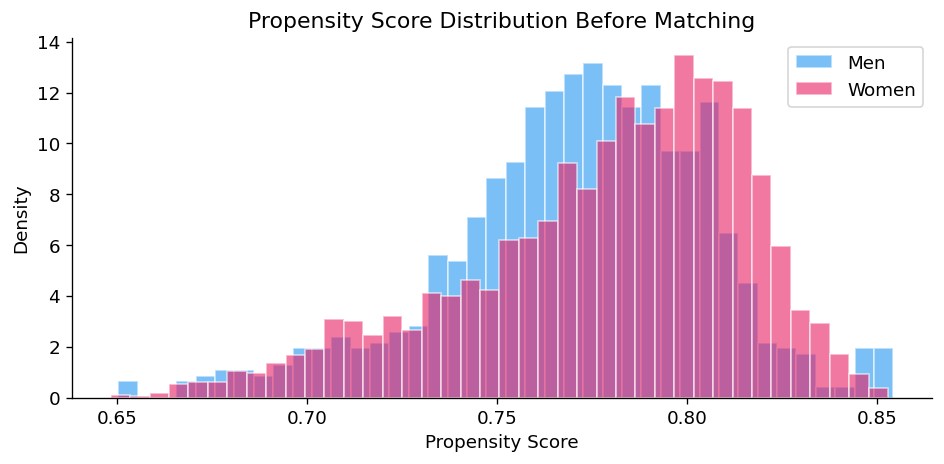

In [12]:
def compute_propensity_scores(df, covariates=['Age']):
    """Logistic regression to estimate P(Women | covariates)."""
    X = df[covariates].values
    y = df['SexCode'].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_scaled, y)
    ps = lr.predict_proba(X_scaled)[:, 1]
    return ps

df['PS'] = compute_propensity_scores(df, covariates=['Age'])

fig, ax = plt.subplots(figsize=(8, 4))
for sex in ['Men', 'Women']:
    sub = df[df['SexLabel'] == sex]['PS']
    ax.hist(sub, bins=40, alpha=0.6, color=COLORS[sex], label=sex, density=True, edgecolor='white')
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Distribution Before Matching')
ax.legend()
plt.tight_layout()
plt.savefig('fig_psm_before.png', bbox_inches='tight')
plt.show()

### 3.2 1:1 Nearest-neighbour matching without replacement

In [13]:
def psm_match(df, caliper=0.2):
    """
    1:1 nearest-neighbour PSM.
    caliper: max allowed difference in logit(PS) (0.2 × SD of logit PS is standard).
    Returns matched dataframe.
    """
    men_idx   = df[df['SexLabel'] == 'Men'].index
    women_idx = df[df['SexLabel'] == 'Women'].index

    logit_ps = np.log(df['PS'] / (1 - df['PS'] + 1e-10))
    caliper_val = caliper * logit_ps.std()

    men_ps   = logit_ps[men_idx].values.reshape(-1, 1)
    women_ps = logit_ps[women_idx].values.reshape(-1, 1)

    nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
    nn.fit(women_ps)
    distances, indices = nn.kneighbors(men_ps)

    matched_men   = []
    matched_women = []
    used_women    = set()

    for i, (dist, idx) in enumerate(zip(distances.flatten(), indices.flatten())):
        if dist <= caliper_val and idx not in used_women:
            matched_men.append(men_idx[i])
            matched_women.append(women_idx[idx])
            used_women.add(idx)

    matched_idx = matched_men + matched_women
    matched_df  = df.loc[matched_idx].copy()
    print(f'Matched pairs: {len(matched_men)}')
    print(f'Men retained : {len(matched_men)} / {len(men_idx)}')
    print(f'Women retained: {len(matched_women)} / {len(women_idx)}')
    return matched_df

df_matched = psm_match(df)
print()
print(df_matched.groupby('SexLabel').size().rename('N'))

Matched pairs: 710
Men retained : 710 / 910
Women retained: 710 / 3175

SexLabel
Men      710
Women    710
Name: N, dtype: int64


### 3.3 Check balance after matching (standardised mean difference)

Before PSM      — SMD(Age) = 0.217  (< 0.1 = well-balanced)
After PSM       — SMD(Age) = 0.000  (< 0.1 = well-balanced)


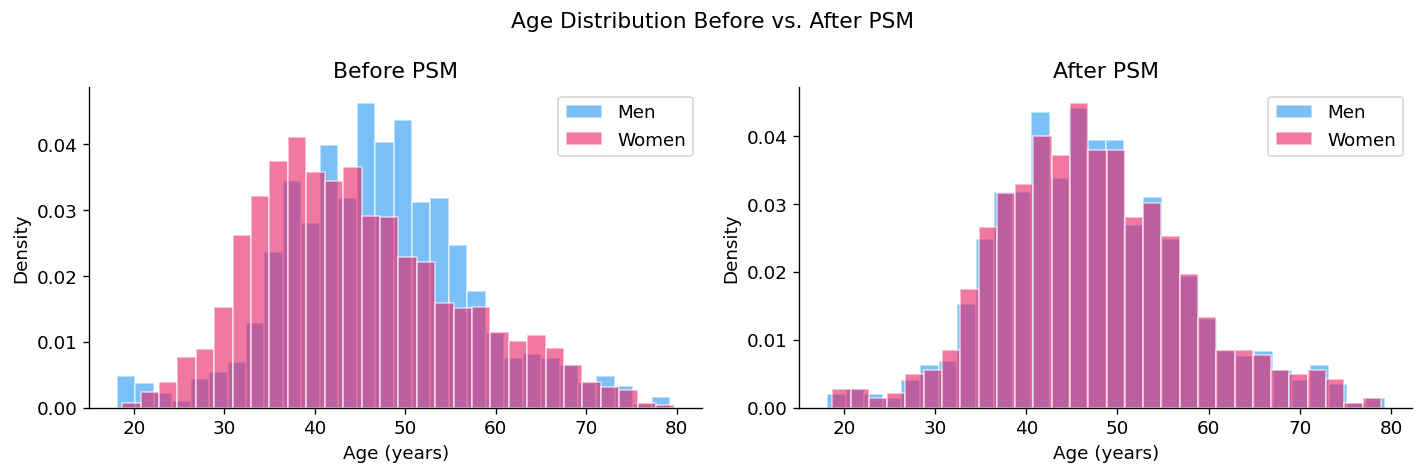

In [14]:
def standardised_mean_diff(df, var='Age'):
    men   = df[df['SexLabel'] == 'Men'][var]
    women = df[df['SexLabel'] == 'Women'][var]
    pooled_sd = np.sqrt((men.var() + women.var()) / 2)
    return abs(men.mean() - women.mean()) / pooled_sd

for label, data in [('Before PSM', df), ('After PSM', df_matched)]:
    smd = standardised_mean_diff(data, 'Age')
    print(f'{label:15s} — SMD(Age) = {smd:.3f}  (< 0.1 = well-balanced)')

# Visualise age distribution after matching
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, data) in zip(axes, [('Before PSM', df), ('After PSM', df_matched)]):
    for sex in ['Men', 'Women']:
        sub = data[data['SexLabel'] == sex]['Age']
        ax.hist(sub, bins=30, alpha=0.6, color=COLORS[sex], label=sex, density=True, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('Age Distribution Before vs. After PSM', fontsize=13)
plt.tight_layout()
plt.savefig('fig_psm_balance.png', bbox_inches='tight')
plt.show()

---
## Phase 4: Regression Assumption Checking

### 4.1 Helper: fit piecewise OLS and return residuals

In [15]:
def fit_piecewise_ols(sub_df, freq, bp=BREAKPOINT):
    """
    Fit piecewise linear regression with fixed breakpoint.
    Model: threshold ~ Age_below + Age_above
    where Age_below = Age if Age < bp else bp
          Age_above = 0  if Age < bp else (Age - bp)
    Returns fitted OLS result object.
    """
    d = sub_df[['Age', freq]].dropna().copy()
    d['Age_below'] = d['Age'].clip(upper=bp)
    d['Age_above'] = (d['Age'] - bp).clip(lower=0)
    y = d[freq]
    X = sm.add_constant(d[['Age_below', 'Age_above']])
    model = sm.OLS(y, X).fit()
    return model, d

print('Helper function defined.')

Helper function defined.


### 4.2 Normality of residuals — Shapiro-Wilk test

In [16]:
normality_results = []

for sex in ['Men', 'Women']:
    sub = df[df['SexLabel'] == sex]
    for freq in FREQS:
        model, _ = fit_piecewise_ols(sub, freq)
        resid = model.resid
        # Shapiro-Wilk (accurate up to n=5000; use KS for larger)
        if len(resid) <= 5000:
            stat, p = shapiro(resid)
            test = 'Shapiro-Wilk'
        else:
            stat, p = kstest(resid, 'norm', args=(resid.mean(), resid.std()))
            test = 'KS'
        normality_results.append({
            'Sex': sex, 'Freq': freq, 'Test': test,
            'Statistic': round(stat, 4), 'p-value': round(p, 4),
            'Normal (α=0.05)': 'Yes' if p > 0.05 else 'No'
        })

norm_df = pd.DataFrame(normality_results)
print(norm_df.to_string(index=False))

  Sex    Freq         Test  Statistic  p-value Normal (α=0.05)
  Men 0.25kHz Shapiro-Wilk     0.9719      0.0              No
  Men  0.5kHz Shapiro-Wilk     0.9617      0.0              No
  Men    1kHz Shapiro-Wilk     0.9391      0.0              No
  Men    2kHz Shapiro-Wilk     0.9414      0.0              No
  Men    4kHz Shapiro-Wilk     0.9193      0.0              No
  Men    8kHz Shapiro-Wilk     0.9384      0.0              No
Women 0.25kHz Shapiro-Wilk     0.9658      0.0              No
Women  0.5kHz Shapiro-Wilk     0.9475      0.0              No
Women    1kHz Shapiro-Wilk     0.9433      0.0              No
Women    2kHz Shapiro-Wilk     0.9456      0.0              No
Women    4kHz Shapiro-Wilk     0.9408      0.0              No
Women    8kHz Shapiro-Wilk     0.9490      0.0              No


### 4.3 QQ-plots of residuals

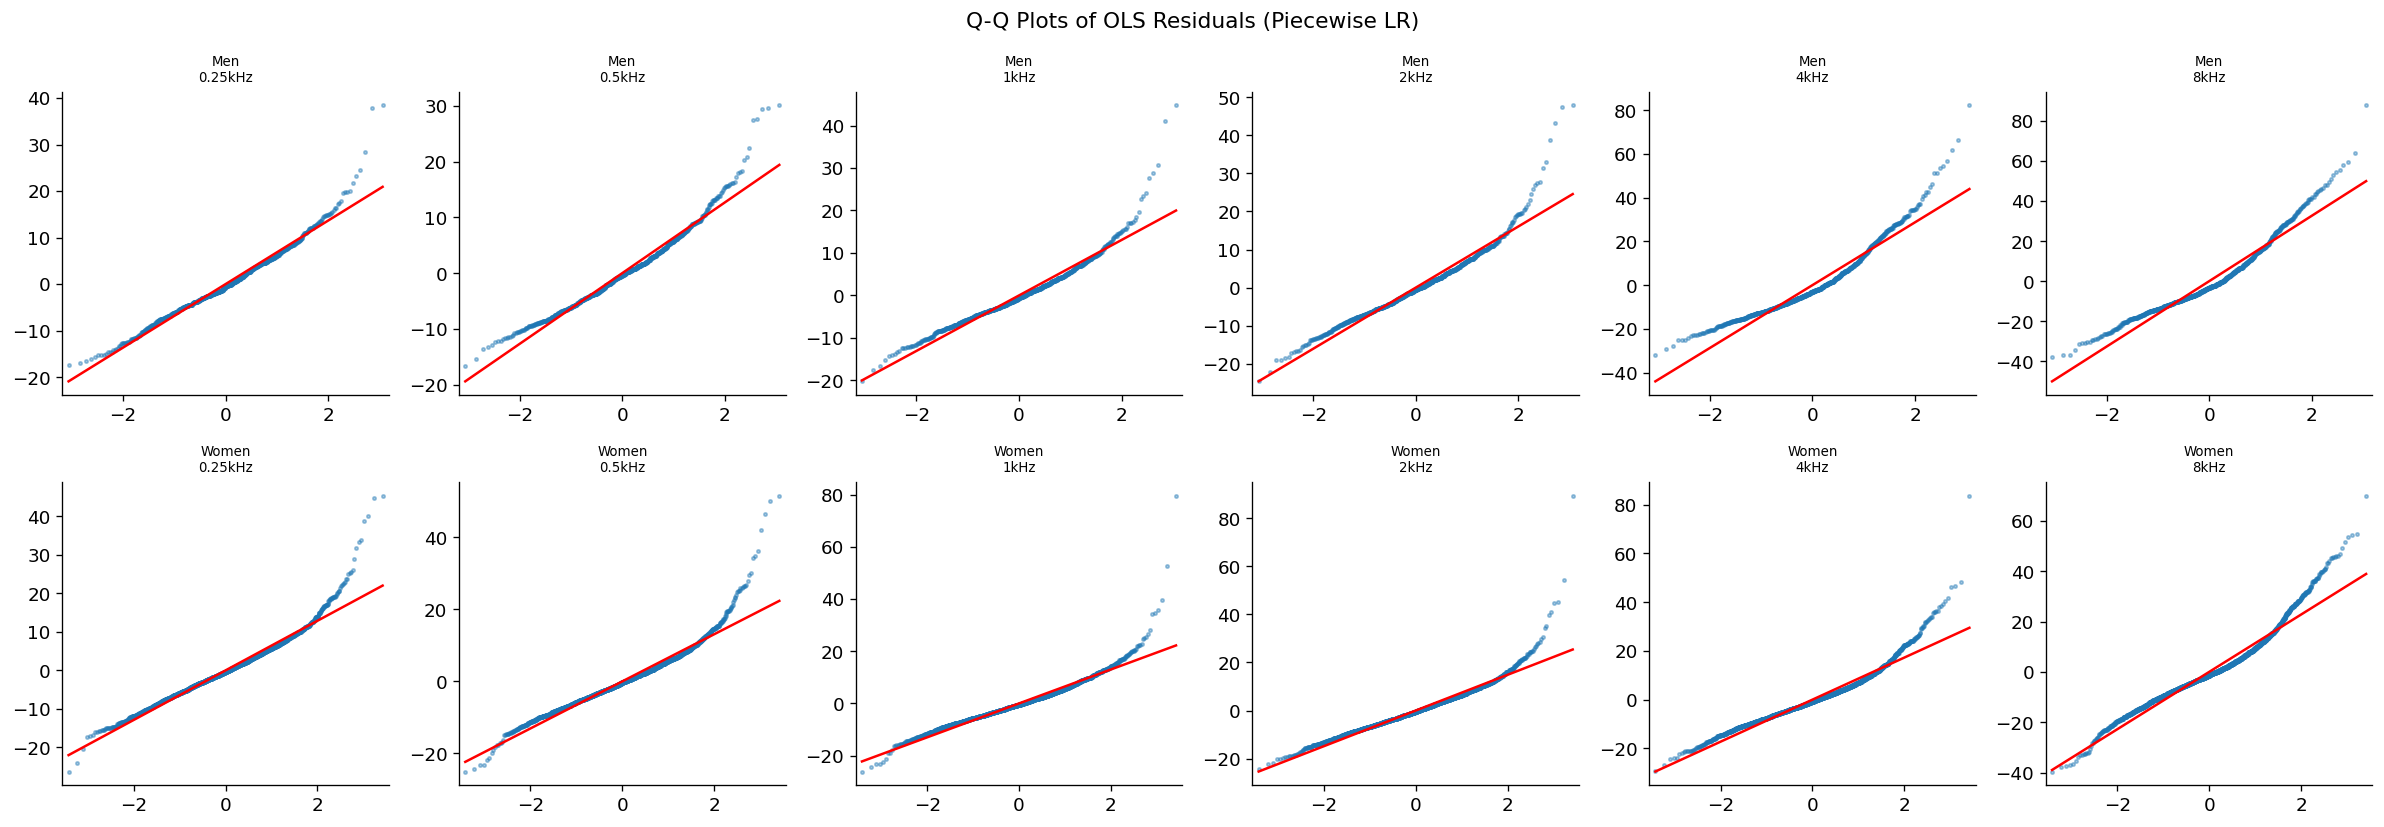

In [17]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for row, sex in enumerate(['Men', 'Women']):
    sub = df[df['SexLabel'] == sex]
    for col, freq in enumerate(FREQS):
        ax = axes[row][col]
        model, _ = fit_piecewise_ols(sub, freq)
        sm.qqplot(model.resid, line='s', ax=ax, alpha=0.4, markersize=2)
        ax.set_title(f'{sex}\n{freq}', fontsize=8)
        ax.set_xlabel('')
        ax.set_ylabel('')

plt.suptitle('Q-Q Plots of OLS Residuals (Piecewise LR)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_qq_plots.png', bbox_inches='tight')
plt.show()

### 4.4 Homoscedasticity — Breusch-Pagan test and residual plots

In [18]:
hetero_results = []

for sex in ['Men', 'Women']:
    sub = df[df['SexLabel'] == sex]
    for freq in FREQS:
        model, d = fit_piecewise_ols(sub, freq)
        lm_stat, lm_p, f_stat, f_p = het_breuschpagan(model.resid, model.model.exog)
        hetero_results.append({
            'Sex': sex, 'Freq': freq,
            'BP Statistic': round(lm_stat, 3), 'BP p-value': round(lm_p, 4),
            'Heteroscedastic': 'Yes' if lm_p < 0.05 else 'No'
        })

het_df = pd.DataFrame(hetero_results)
print(het_df.to_string(index=False))

  Sex    Freq  BP Statistic  BP p-value Heteroscedastic
  Men 0.25kHz        44.814      0.0000             Yes
  Men  0.5kHz        53.697      0.0000             Yes
  Men    1kHz        42.125      0.0000             Yes
  Men    2kHz        29.482      0.0000             Yes
  Men    4kHz        12.616      0.0018             Yes
  Men    8kHz         9.519      0.0086             Yes
Women 0.25kHz       133.661      0.0000             Yes
Women  0.5kHz       135.428      0.0000             Yes
Women    1kHz        84.244      0.0000             Yes
Women    2kHz        94.503      0.0000             Yes
Women    4kHz       161.509      0.0000             Yes
Women    8kHz       271.622      0.0000             Yes


### 4.5 Residual vs. fitted plots

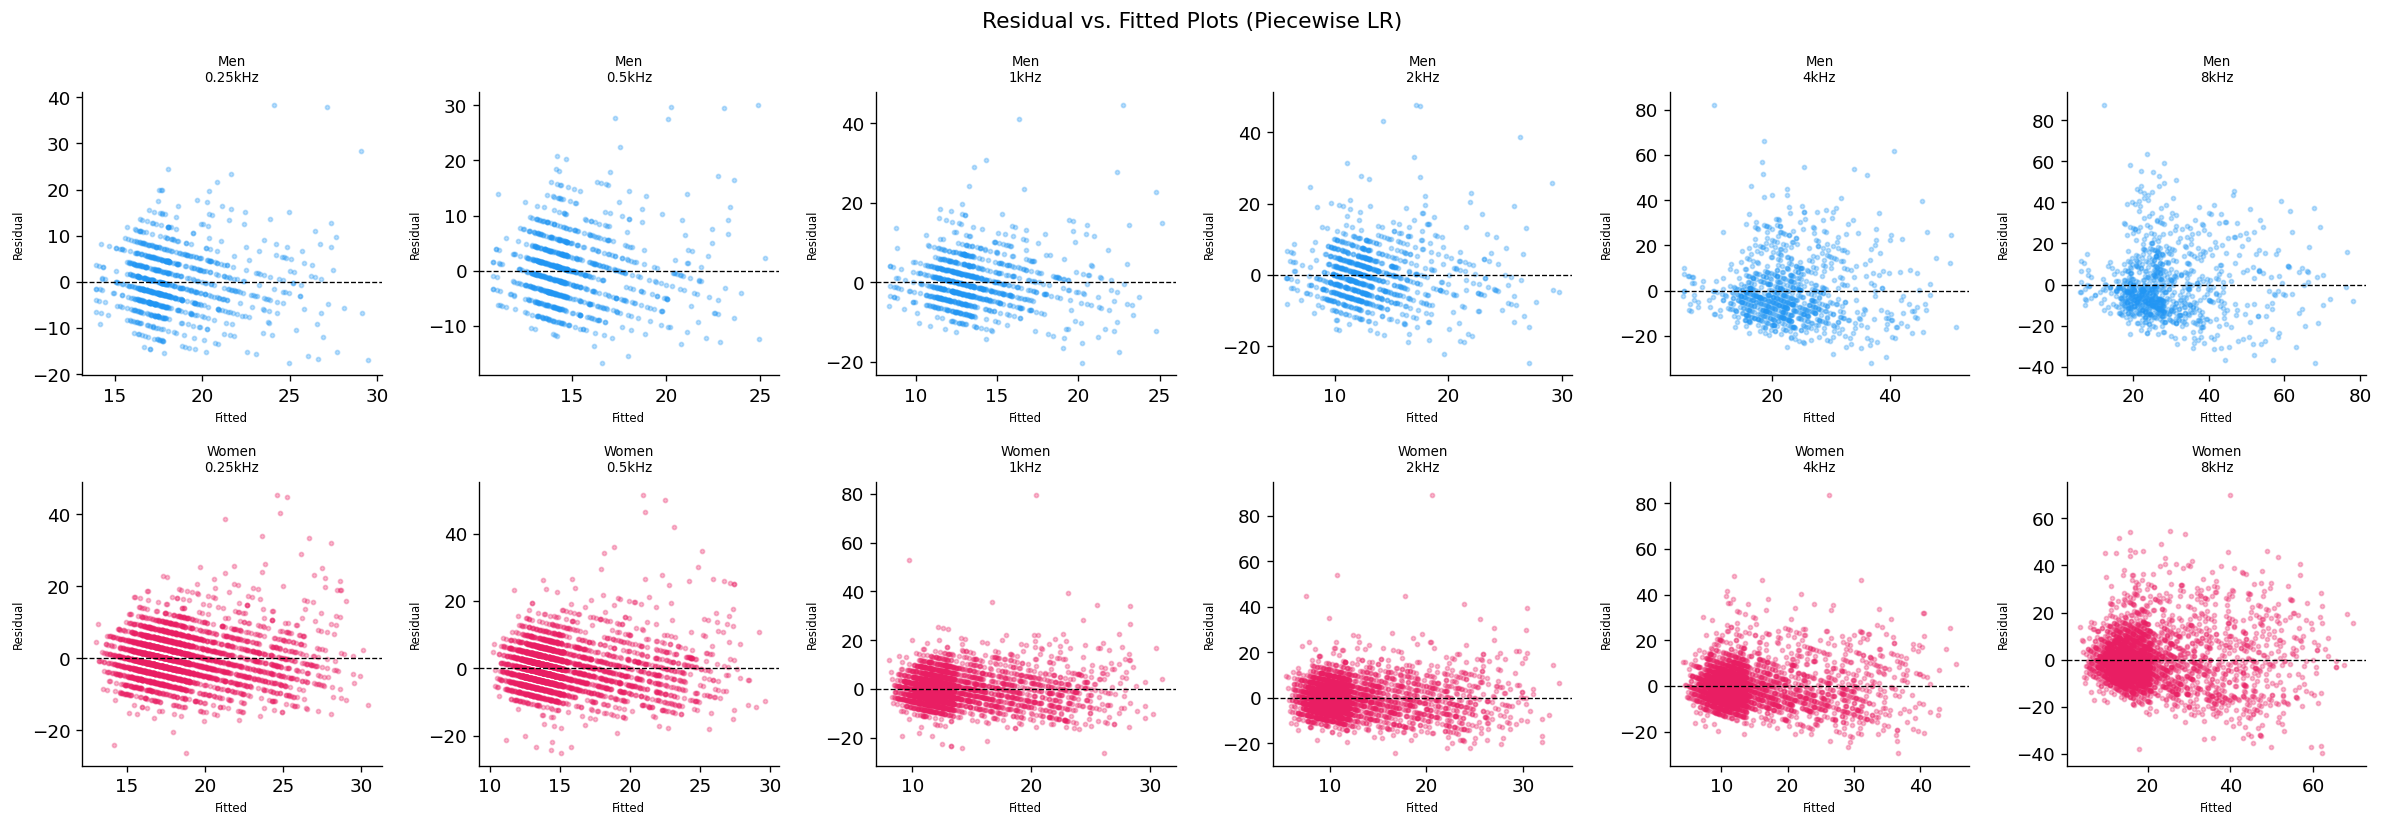

In [19]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for row, sex in enumerate(['Men', 'Women']):
    sub = df[df['SexLabel'] == sex]
    for col, freq in enumerate(FREQS):
        ax = axes[row][col]
        model, _ = fit_piecewise_ols(sub, freq)
        ax.scatter(model.fittedvalues, model.resid, alpha=0.3,
                   s=6, color=COLORS[sex])
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(f'{sex}\n{freq}', fontsize=8)
        ax.set_xlabel('Fitted', fontsize=7)
        ax.set_ylabel('Residual', fontsize=7)

plt.suptitle('Residual vs. Fitted Plots (Piecewise LR)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_resid_fitted.png', bbox_inches='tight')
plt.show()

### 4.6 Residual SD by age-decile (heteroscedasticity visualised)

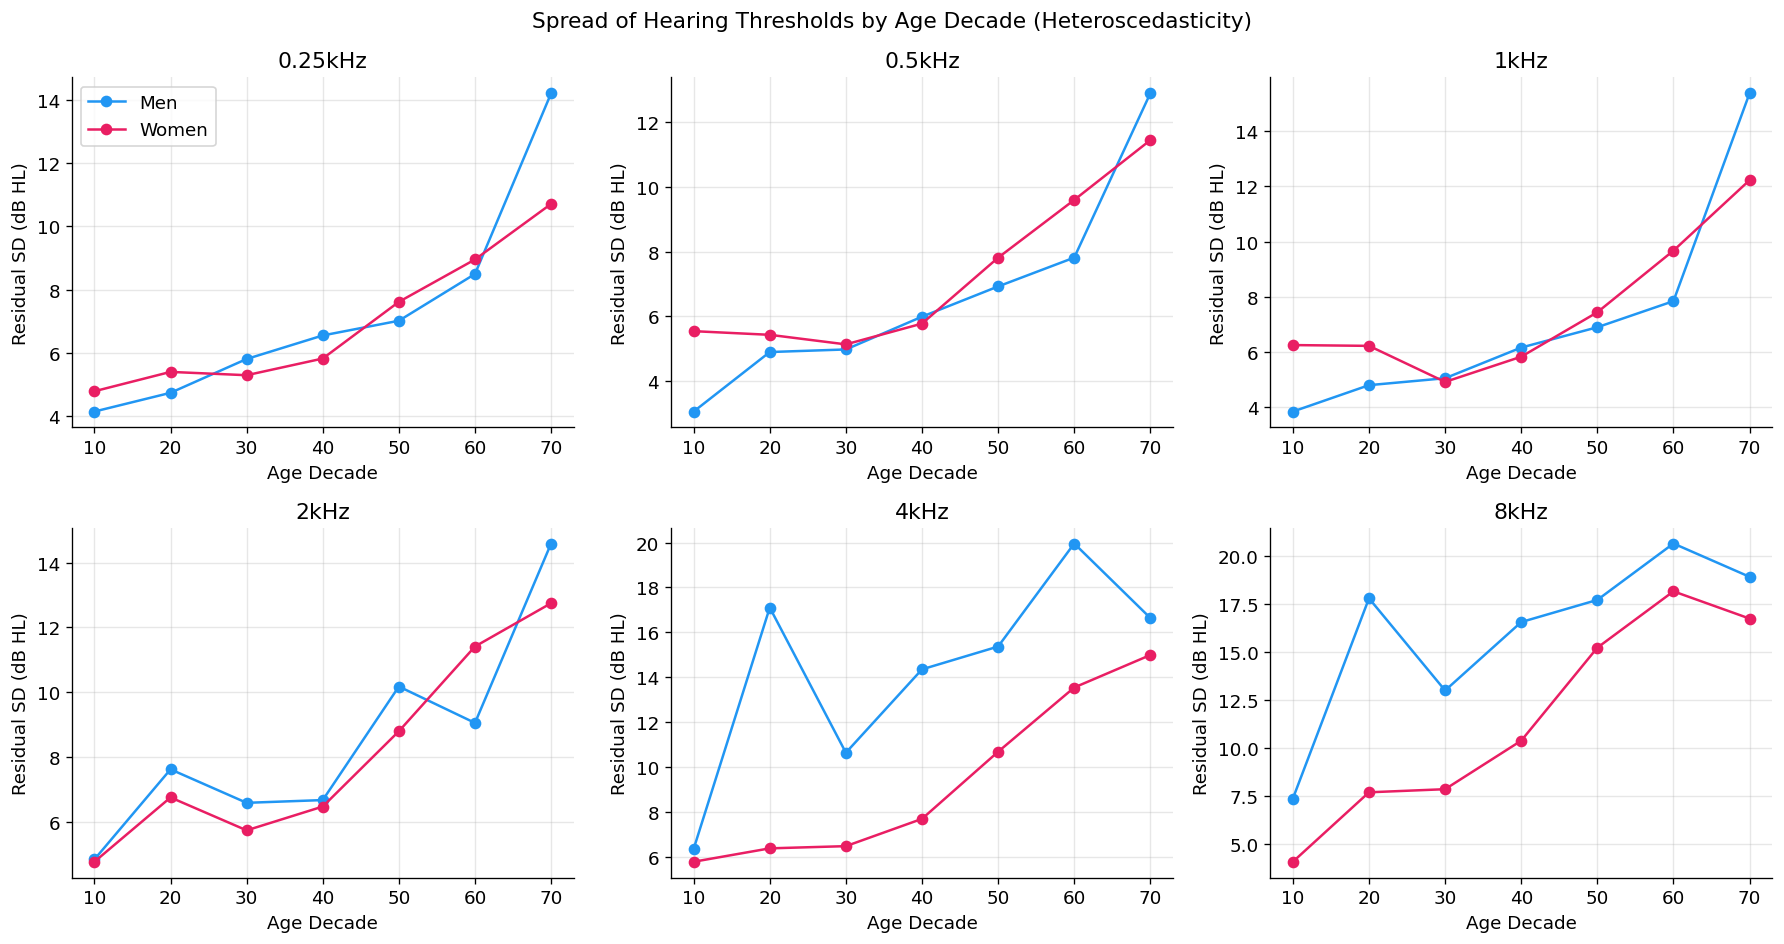

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, freq in zip(axes, FREQS):
    for sex in ['Men', 'Women']:
        sub = df[df['SexLabel'] == sex][['Age', freq]].dropna()
        sub = sub.copy()
        sub['decade'] = (sub['Age'] // 10 * 10).astype(int)
        sd_by_decade = sub.groupby('decade')[freq].std().reset_index()
        ax.plot(sd_by_decade['decade'], sd_by_decade[freq],
                marker='o', color=COLORS[sex], label=sex)
    ax.set_title(freq)
    ax.set_xlabel('Age Decade')
    ax.set_ylabel('Residual SD (dB HL)')
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.suptitle('Spread of Hearing Thresholds by Age Decade (Heteroscedasticity)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_hetero_by_decade.png', bbox_inches='tight')
plt.show()

### 4.7 Outlier detection — Cook's Distance

In [21]:
outlier_counts = []

for sex in ['Men', 'Women']:
    sub = df[df['SexLabel'] == sex]
    for freq in FREQS:
        model, d = fit_piecewise_ols(sub, freq)
        influence = model.get_influence()
        cooks_d   = influence.cooks_distance[0]
        threshold = 4 / len(d)
        n_outliers = (cooks_d > threshold).sum()
        outlier_counts.append({
            'Sex': sex, 'Freq': freq,
            'N Outliers (Cook\'s D)': n_outliers,
            'Threshold': round(threshold, 5),
            'Pct': round(100 * n_outliers / len(d), 2)
        })

outlier_df = pd.DataFrame(outlier_counts)
print(outlier_df.to_string(index=False))

  Sex    Freq  N Outliers (Cook's D)  Threshold  Pct
  Men 0.25kHz                     42    0.00440 4.62
  Men  0.5kHz                     42    0.00440 4.62
  Men    1kHz                     47    0.00440 5.16
  Men    2kHz                     48    0.00440 5.27
  Men    4kHz                     41    0.00440 4.51
  Men    8kHz                     41    0.00440 4.51
Women 0.25kHz                    174    0.00126 5.48
Women  0.5kHz                    177    0.00126 5.57
Women    1kHz                    184    0.00126 5.80
Women    2kHz                    181    0.00126 5.70
Women    4kHz                    215    0.00126 6.77
Women    8kHz                    235    0.00126 7.40


---
## Phase 5: Violation Remedies

### 5.1 Weighted Least Squares (WLS) — inverse variance weights by age decile

In [22]:
def compute_wls_weights(d, freq, bp=BREAKPOINT):
    """Assign weights = 1 / variance within each 5-year age bin."""
    d = d.copy()
    d['bin'] = pd.cut(d['Age'], bins=np.arange(15, 85, 5))
    var_by_bin = d.groupby('bin')[freq].var().rename('var')
    d = d.join(var_by_bin, on='bin')
    d['weight'] = 1 / d['var'].clip(lower=1e-4)
    return d['weight']

def fit_piecewise_wls(sub_df, freq, bp=BREAKPOINT):
    """Piecewise WLS with inverse-variance weights."""
    d = sub_df[['Age', freq]].dropna().copy()
    d['Age_below'] = d['Age'].clip(upper=bp)
    d['Age_above'] = (d['Age'] - bp).clip(lower=0)
    y = d[freq]
    X = sm.add_constant(d[['Age_below', 'Age_above']])
    weights = compute_wls_weights(d, freq, bp)
    model = sm.WLS(y, X, weights=weights).fit()
    return model, d

print('WLS helper defined.')

WLS helper defined.


### 5.2 Robust standard errors (HC3) — OLS with sandwich covariance

In [23]:
def fit_piecewise_robust(sub_df, freq, bp=BREAKPOINT):
    """OLS with HC3 heteroscedasticity-consistent standard errors."""
    d = sub_df[['Age', freq]].dropna().copy()
    d['Age_below'] = d['Age'].clip(upper=bp)
    d['Age_above'] = (d['Age'] - bp).clip(lower=0)
    y = d[freq]
    X = sm.add_constant(d[['Age_below', 'Age_above']])
    model = sm.OLS(y, X).fit(cov_type='HC3')
    return model, d

print('Robust SE helper defined.')

Robust SE helper defined.


### 5.3 Bootstrap BCa confidence intervals for slopes

In [24]:
def bootstrap_slopes(sub_df, freq, bp=BREAKPOINT, n_boot=2000, ci=95, seed=42):
    """
    Non-parametric bootstrap (BCa) for piecewise LR slopes.
    Returns dict with point estimate and BCa CI for slope_below and slope_above.
    """
    rng = np.random.default_rng(seed)
    d = sub_df[['Age', freq]].dropna().copy().reset_index(drop=True)
    n = len(d)

    def get_slopes(data):
        data = data.copy()
        data['Age_below'] = data['Age'].clip(upper=bp)
        data['Age_above'] = (data['Age'] - bp).clip(lower=0)
        y = data[freq]
        X = sm.add_constant(data[['Age_below', 'Age_above']])
        res = sm.OLS(y, X).fit()
        return res.params['Age_below'], res.params['Age_above']

    # Observed
    obs_below, obs_above = get_slopes(d)

    # Bootstrap
    boot_below = np.zeros(n_boot)
    boot_above = np.zeros(n_boot)
    for i in range(n_boot):
        idx  = rng.integers(0, n, size=n)
        boot = d.iloc[idx]
        try:
            b, a = get_slopes(boot)
            boot_below[i] = b
            boot_above[i] = a
        except Exception:
            boot_below[i] = obs_below
            boot_above[i] = obs_above

    alpha = (100 - ci) / 100
    lo, hi = np.percentile(boot_below, [alpha/2*100, (1-alpha/2)*100])
    lo2, hi2 = np.percentile(boot_above, [alpha/2*100, (1-alpha/2)*100])

    return {
        'slope_below': obs_below, 'CI_below': (lo, hi),
        'slope_above': obs_above, 'CI_above': (lo2, hi2),
        'boot_below': boot_below,
        'boot_above': boot_above
    }

print('Bootstrap helper defined. Running bootstrap (this may take 1-2 min)...')

Bootstrap helper defined. Running bootstrap (this may take 1-2 min)...


In [25]:
# Run bootstrap for all sex × frequency combinations
bootstrap_results = {}
for sex in ['Men', 'Women']:
    sub = df[df['SexLabel'] == sex]
    for freq in FREQS:
        key = (sex, freq)
        bootstrap_results[key] = bootstrap_slopes(sub, freq, n_boot=2000)
        r = bootstrap_results[key]
        print(f"{sex:6s} {freq:7s} | "
              f"Below: {r['slope_below']:+.3f} dB/yr [{r['CI_below'][0]:+.3f}, {r['CI_below'][1]:+.3f}]  "
              f"Above: {r['slope_above']:+.3f} dB/yr [{r['CI_above'][0]:+.3f}, {r['CI_above'][1]:+.3f}]")

Men    0.25kHz | Below: +0.135 dB/yr [+0.066, +0.196]  Above: +0.379 dB/yr [+0.257, +0.517]
Men    0.5kHz  | Below: +0.128 dB/yr [+0.064, +0.188]  Above: +0.348 dB/yr [+0.234, +0.469]
Men    1kHz    | Below: +0.167 dB/yr [+0.105, +0.230]  Above: +0.385 dB/yr [+0.261, +0.524]
Men    2kHz    | Below: +0.238 dB/yr [+0.164, +0.317]  Above: +0.553 dB/yr [+0.426, +0.695]
Men    4kHz    | Below: +0.600 dB/yr [+0.454, +0.737]  Above: +0.918 dB/yr [+0.706, +1.128]
Men    8kHz    | Below: +0.710 dB/yr [+0.542, +0.860]  Above: +1.664 dB/yr [+1.442, +1.879]
Women  0.25kHz | Below: +0.197 dB/yr [+0.162, +0.230]  Above: +0.375 dB/yr [+0.312, +0.441]
Women  0.5kHz  | Below: +0.166 dB/yr [+0.132, +0.200]  Above: +0.472 dB/yr [+0.406, +0.537]
Women  1kHz    | Below: +0.177 dB/yr [+0.141, +0.211]  Above: +0.574 dB/yr [+0.510, +0.638]
Women  2kHz    | Below: +0.214 dB/yr [+0.173, +0.253]  Above: +0.708 dB/yr [+0.633, +0.781]
Women  4kHz    | Below: +0.312 dB/yr [+0.269, +0.355]  Above: +1.034 dB/yr [+0.9

### 5.4 FDR correction (Benjamini-Hochberg) across all tests

In [26]:
def collect_ancova_pvalues(df, freqs=FREQS, bp=BREAKPOINT):
    """
    Run ANCOVA (threshold ~ Sex + Age) for each frequency × age group.
    Returns DataFrame of raw p-values and sex coefficient.
    """
    records = []
    for age_grp, grp_label in [('below', f'< {bp}'), ('above', f'≥ {bp}')]:
        if age_grp == 'below':
            sub = df[df['Age'] < bp].copy()
        else:
            sub = df[df['Age'] >= bp].copy()
        for freq in freqs:
            d = sub[['SexCode', 'Age', freq]].dropna().copy()
            X = sm.add_constant(d[['SexCode', 'Age']])
            y = d[freq]
            res = sm.OLS(y, X).fit(cov_type='HC3')
            p_sex = res.pvalues['SexCode']
            coef  = res.params['SexCode']
            records.append({
                'AgeGroup': grp_label, 'Freq': freq,
                'SexCoef (dB)': round(coef, 3),
                'Raw p': round(p_sex, 4)
            })
    return pd.DataFrame(records)

ancova_df = collect_ancova_pvalues(df)

# Apply BH FDR correction
reject, p_fdr, _, _ = multipletests(ancova_df['Raw p'], alpha=0.05, method='fdr_bh')
ancova_df['FDR-adj p'] = p_fdr.round(4)
ancova_df['Significant'] = reject

print('=== ANCOVA: Sex Differences by Frequency and Age Group ===')
print('(Age-adjusted; HC3 SEs; BH FDR-corrected)')
print()
print(ancova_df.to_string(index=False))

=== ANCOVA: Sex Differences by Frequency and Age Group ===
(Age-adjusted; HC3 SEs; BH FDR-corrected)

AgeGroup    Freq  SexCoef (dB)  Raw p  FDR-adj p  Significant
  < 49.3 0.25kHz         0.457 0.1134     0.1701        False
  < 49.3  0.5kHz        -0.046 0.8602     0.8602        False
  < 49.3    1kHz        -0.370 0.1676     0.2011        False
  < 49.3    2kHz        -0.851 0.0069     0.0118         True
  < 49.3    4kHz        -7.300 0.0000     0.0000         True
  < 49.3    8kHz        -6.589 0.0000     0.0000         True
  ≥ 49.3 0.25kHz         0.694 0.1626     0.2011        False
  ≥ 49.3  0.5kHz         1.694 0.0005     0.0012         True
  ≥ 49.3    1kHz         1.716 0.0006     0.0012         True
  ≥ 49.3    2kHz         0.227 0.7110     0.7756        False
  ≥ 49.3    4kHz        -8.709 0.0000     0.0000         True
  ≥ 49.3    8kHz        -6.942 0.0000     0.0000         True


---
## Phase 6: Model Building & Visualisation

### 6.1 OLS vs WLS vs Robust — slope comparison table

In [27]:
comparison_rows = []

for sex in ['Men', 'Women']:
    sub = df[df['SexLabel'] == sex]
    for freq in FREQS:
        # OLS
        m_ols, _ = fit_piecewise_ols(sub, freq)
        # WLS
        m_wls, _ = fit_piecewise_wls(sub, freq)
        # Robust
        m_rob, _ = fit_piecewise_robust(sub, freq)
        # Bootstrap BCa
        bsr = bootstrap_results[(sex, freq)]

        for segment, param in [('Below 49.3', 'Age_below'), ('Above 49.3', 'Age_above')]:
            comparison_rows.append({
                'Sex': sex, 'Freq': freq, 'Segment': segment,
                'OLS slope':    round(m_ols.params[param], 4),
                'OLS SE':       round(m_ols.bse[param], 4),
                'WLS slope':    round(m_wls.params[param], 4),
                'WLS SE':       round(m_wls.bse[param], 4),
                'Robust slope': round(m_rob.params[param], 4),
                'Robust SE':    round(m_rob.bse[param], 4),
                'Boot CI lo':   round(bsr['CI_below'][0] if 'Below' in segment else bsr['CI_above'][0], 4),
                'Boot CI hi':   round(bsr['CI_below'][1] if 'Below' in segment else bsr['CI_above'][1], 4),
            })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))
comp_df.to_csv('slope_comparison_OLS_WLS_Robust_Bootstrap.csv', index=False)
print('\nSaved: slope_comparison_OLS_WLS_Robust_Bootstrap.csv')

  Sex    Freq    Segment  OLS slope  OLS SE  WLS slope  WLS SE  Robust slope  Robust SE  Boot CI lo  Boot CI hi
  Men 0.25kHz Below 49.3     0.1352  0.0376     0.1442  0.0303        0.1352     0.0331      0.0664      0.1962
  Men 0.25kHz Above 49.3     0.3794  0.0448     0.3390  0.0578        0.3794     0.0696      0.2574      0.5170
  Men  0.5kHz Below 49.3     0.1277  0.0350     0.1387  0.0267        0.1277     0.0308      0.0643      0.1875
  Men  0.5kHz Above 49.3     0.3484  0.0416     0.2921  0.0530        0.3484     0.0642      0.2341      0.4695
  Men    1kHz Below 49.3     0.1670  0.0360     0.1806  0.0286        0.1670     0.0319      0.1051      0.2298
  Men    1kHz Above 49.3     0.3845  0.0428     0.3358  0.0559        0.3845     0.0713      0.2613      0.5243
  Men    2kHz Below 49.3     0.2375  0.0442     0.2233  0.0342        0.2375     0.0388      0.1644      0.3168
  Men    2kHz Above 49.3     0.5531  0.0527     0.5284  0.0623        0.5531     0.0719      0.4265     

### 6.2 Piecewise LR scatterplots (replication of Figure 3)

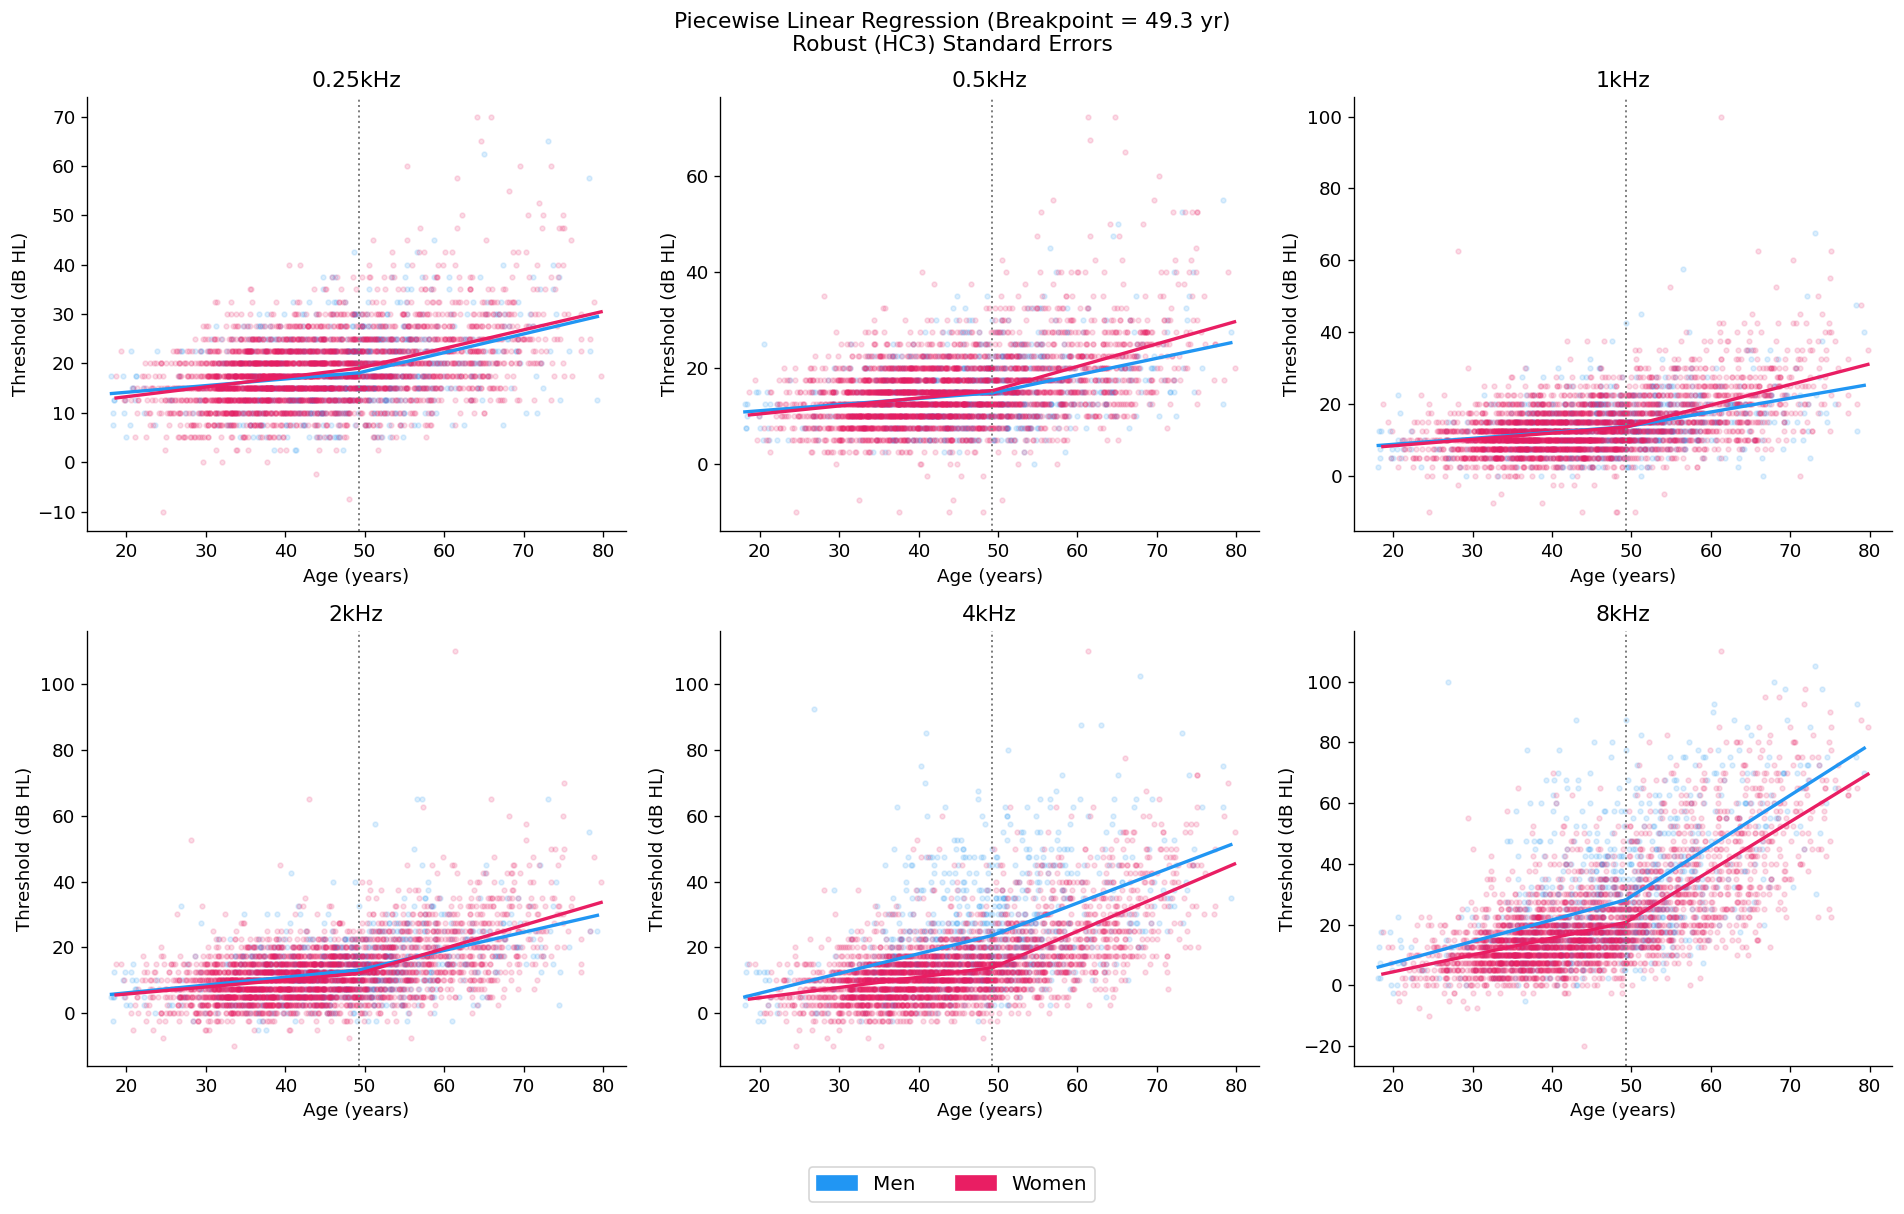

In [28]:
def plot_piecewise_scatter(df, freq, bp=BREAKPOINT, method='robust', ax=None):
    """Scatter + piecewise regression lines for one frequency."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    for sex in ['Men', 'Women']:
        sub = df[df['SexLabel'] == sex][['Age', freq]].dropna()
        ax.scatter(sub['Age'], sub[freq], alpha=0.15, s=8,
                   color=COLORS[sex], label=sex)

        # Fit
        if method == 'robust':
            model, d = fit_piecewise_robust(sub, freq)
        elif method == 'wls':
            model, d = fit_piecewise_wls(sub, freq)
        else:
            model, d = fit_piecewise_ols(sub, freq)

        # Predicted line
        age_range_below = np.linspace(sub['Age'].min(), bp, 60)
        age_range_above = np.linspace(bp, sub['Age'].max(), 60)

        for age_range in [age_range_below, age_range_above]:
            X_pred = pd.DataFrame({
                'const': 1,
                'Age_below': np.clip(age_range, None, bp),
                'Age_above': np.clip(age_range - bp, 0, None)
            })
            y_pred = model.predict(X_pred)
            ax.plot(age_range, y_pred, color=COLORS[sex], linewidth=2)

    ax.axvline(bp, color='gray', linestyle=':', linewidth=1.2)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Threshold (dB HL)')
    ax.set_title(freq)
    return ax


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, freq in zip(axes, FREQS):
    plot_piecewise_scatter(df, freq, method='robust', ax=ax)

handles = [mpatches.Patch(color=COLORS[s], label=s) for s in ['Men', 'Women']]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=12,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle(
    f'Piecewise Linear Regression (Breakpoint = {BREAKPOINT} yr)\n'
    'Robust (HC3) Standard Errors', fontsize=13
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('fig_piecewise_scatter.png', bbox_inches='tight')
plt.show()

### 6.3 Rate-of-decline bar plot with bootstrap BCa CI (replication of Figure 4)

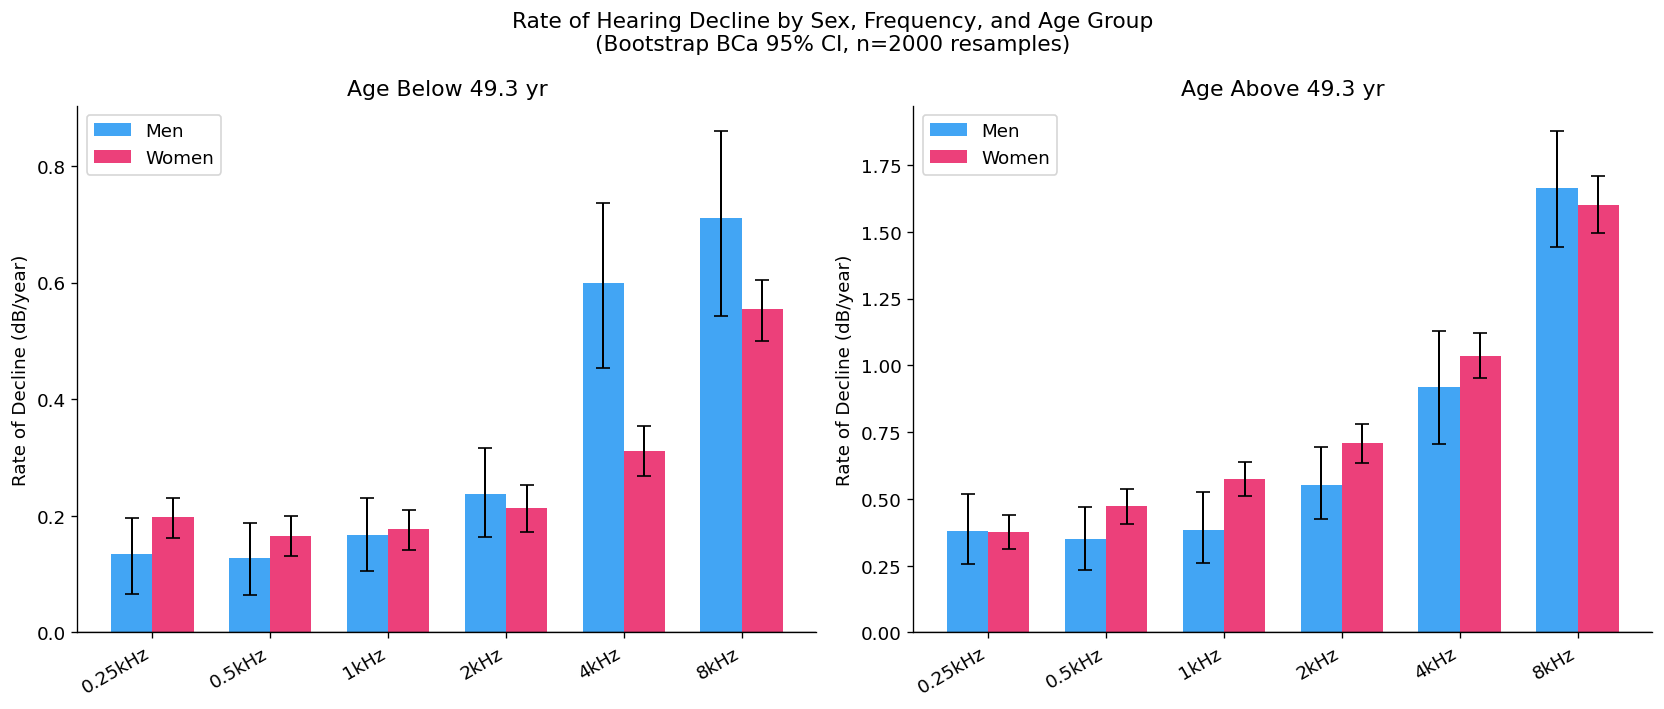

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
segment_labels = ['Below 49.3 yr', 'Above 49.3 yr']
segment_keys   = ['below', 'above']

for ax, (seg_label, seg_key) in zip(axes, zip(segment_labels, segment_keys)):
    x     = np.arange(len(FREQS))
    width = 0.35

    for offset, sex in zip([-width/2, width/2], ['Men', 'Women']):
        slopes = [bootstrap_results[(sex, f)][f'slope_{seg_key}'] for f in FREQS]
        lo_ci  = [bootstrap_results[(sex, f)][f'CI_{seg_key}'][0] for f in FREQS]
        hi_ci  = [bootstrap_results[(sex, f)][f'CI_{seg_key}'][1] for f in FREQS]
        yerr   = np.array([np.array(slopes) - np.array(lo_ci),
                           np.array(hi_ci)  - np.array(slopes)])

        ax.bar(x + offset, slopes, width, label=sex,
               color=COLORS[sex], alpha=0.85,
               yerr=yerr, capsize=4, error_kw={'linewidth': 1.2})

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(FREQS, rotation=30, ha='right')
    ax.set_ylabel('Rate of Decline (dB/year)')
    ax.set_title(f'Age {seg_label}')
    ax.legend()

plt.suptitle('Rate of Hearing Decline by Sex, Frequency, and Age Group\n'
             '(Bootstrap BCa 95% CI, n=2000 resamples)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_rate_of_decline.png', bbox_inches='tight')
plt.show()

### 6.4 Slope sex-difference test: dummy variable regression

In [30]:
def test_slope_sex_diff(df, freq, segment='below', bp=BREAKPOINT):
    """
    Dummy variable regression to test if male and female slopes differ.
    Model: threshold ~ Age_seg + SexCode + Age_seg:SexCode
    Interaction p-value tests H0: slope_men == slope_women.
    """
    d = df[['Age', 'SexCode', freq]].dropna().copy()

    if segment == 'below':
        d = d[d['Age'] < bp].copy()
        d['Age_seg'] = d['Age']
    else:
        d = d[d['Age'] >= bp].copy()
        d['Age_seg'] = d['Age'] - bp

    d['interact'] = d['Age_seg'] * d['SexCode']
    y = d[freq]
    X = sm.add_constant(d[['Age_seg', 'SexCode', 'interact']])
    res = sm.OLS(y, X).fit(cov_type='HC3')
    seg_name = 'Below' if segment == 'below' else 'Above'
    return {
        'Freq': freq,
        'Segment': f'{seg_name} {bp}',
        'Slope_Men':   round(res.params['Age_seg'], 4),
        'Slope_Women': round(res.params['Age_seg'] + res.params['interact'], 4),
        'Interaction_coef': round(res.params['interact'], 4),
        'Interaction_p':    round(res.pvalues['interact'], 4)
    }

sex_diff_rows = []
for freq in FREQS:
    for seg in ['below', 'above']:
        sex_diff_rows.append(test_slope_sex_diff(df, freq, seg))

sex_diff_df = pd.DataFrame(sex_diff_rows)

# FDR correction on interaction p-values
reject_int, p_fdr_int, _, _ = multipletests(sex_diff_df['Interaction_p'],
                                             alpha=0.05, method='fdr_bh')
sex_diff_df['FDR_p'] = p_fdr_int.round(4)
sex_diff_df['Sig (FDR)'] = reject_int

print('=== Sex Difference in Slopes (Interaction Test, HC3 SE, BH-FDR) ===')
print(sex_diff_df.to_string(index=False))
sex_diff_df.to_csv('slope_sex_diff_test.csv', index=False)
print('\nSaved: slope_sex_diff_test.csv')


=== Sex Difference in Slopes (Interaction Test, HC3 SE, BH-FDR) ===
   Freq    Segment  Slope_Men  Slope_Women  Interaction_coef  Interaction_p  FDR_p  Sig (FDR)
0.25kHz Below 49.3     0.1372       0.2177            0.0805         0.0504 0.2016      False
0.25kHz Above 49.3     0.3821       0.4085            0.0264         0.7851 0.8565      False
 0.5kHz Below 49.3     0.1628       0.1672            0.0044         0.9075 0.9075      False
 0.5kHz Above 49.3     0.3965       0.4741            0.0776         0.3965 0.6797      False
   1kHz Below 49.3     0.1907       0.1652           -0.0254         0.5260 0.6878      False
   1kHz Above 49.3     0.4170       0.5541            0.1371         0.1679 0.3358      False
   2kHz Below 49.3     0.2378       0.2118           -0.0261         0.5732 0.6878      False
   2kHz Above 49.3     0.5535       0.7039            0.1504         0.1439 0.3358      False
   4kHz Below 49.3     0.6207       0.3100           -0.3107         0.0002 0.0024    

### 6.5 Sensitivity analysis: Varying the breakpoint (±2 years around 49.3)

In [31]:
BREAKPOINTS_TEST = [47.3, 48.3, 49.3, 50.3, 51.3]
sensitivity_rows = []

for bp in BREAKPOINTS_TEST:
    for sex in ['Men', 'Women']:
        sub = df[df['SexLabel'] == sex]
        for freq in FREQS:
            d = sub[['Age', freq]].dropna().copy()
            d['Age_below'] = d['Age'].clip(upper=bp)
            d['Age_above'] = (d['Age'] - bp).clip(lower=0)
            y = d[freq]
            X = sm.add_constant(d[['Age_below', 'Age_above']])
            try:
                res = sm.OLS(y, X).fit(cov_type='HC3')
                sensitivity_rows.append({
                    'Breakpoint': bp, 'Sex': sex, 'Freq': freq,
                    'Slope_below': round(res.params['Age_below'], 4),
                    'Slope_above': round(res.params['Age_above'], 4),
                    'R2': round(res.rsquared, 4)
                })
            except Exception:
                pass

sens_df = pd.DataFrame(sensitivity_rows)
print('=== Sensitivity: Slopes Across Breakpoints ===')
print(sens_df.groupby(['Breakpoint', 'Sex'])[['Slope_below', 'Slope_above', 'R2']].mean().round(4))
sens_df.to_csv('sensitivity_breakpoints.csv', index=False)
print('\nSaved: sensitivity_breakpoints.csv')

=== Sensitivity: Slopes Across Breakpoints ===
                  Slope_below  Slope_above      R2
Breakpoint Sex                                    
47.3       Men         0.3095       0.6724  0.1987
           Women       0.2424       0.7492  0.3191
48.3       Men         0.3198       0.6894  0.1989
           Women       0.2559       0.7719  0.3197
49.3       Men         0.3295       0.7079  0.1993
           Women       0.2702       0.7940  0.3197
50.3       Men         0.3394       0.7270  0.1995
           Women       0.2845       0.8161  0.3194
51.3       Men         0.3482       0.7480  0.1998
           Women       0.2981       0.8394  0.3190

Saved: sensitivity_breakpoints.csv


### 6.6 Sensitivity analysis: Visualise slope stability across breakpoints

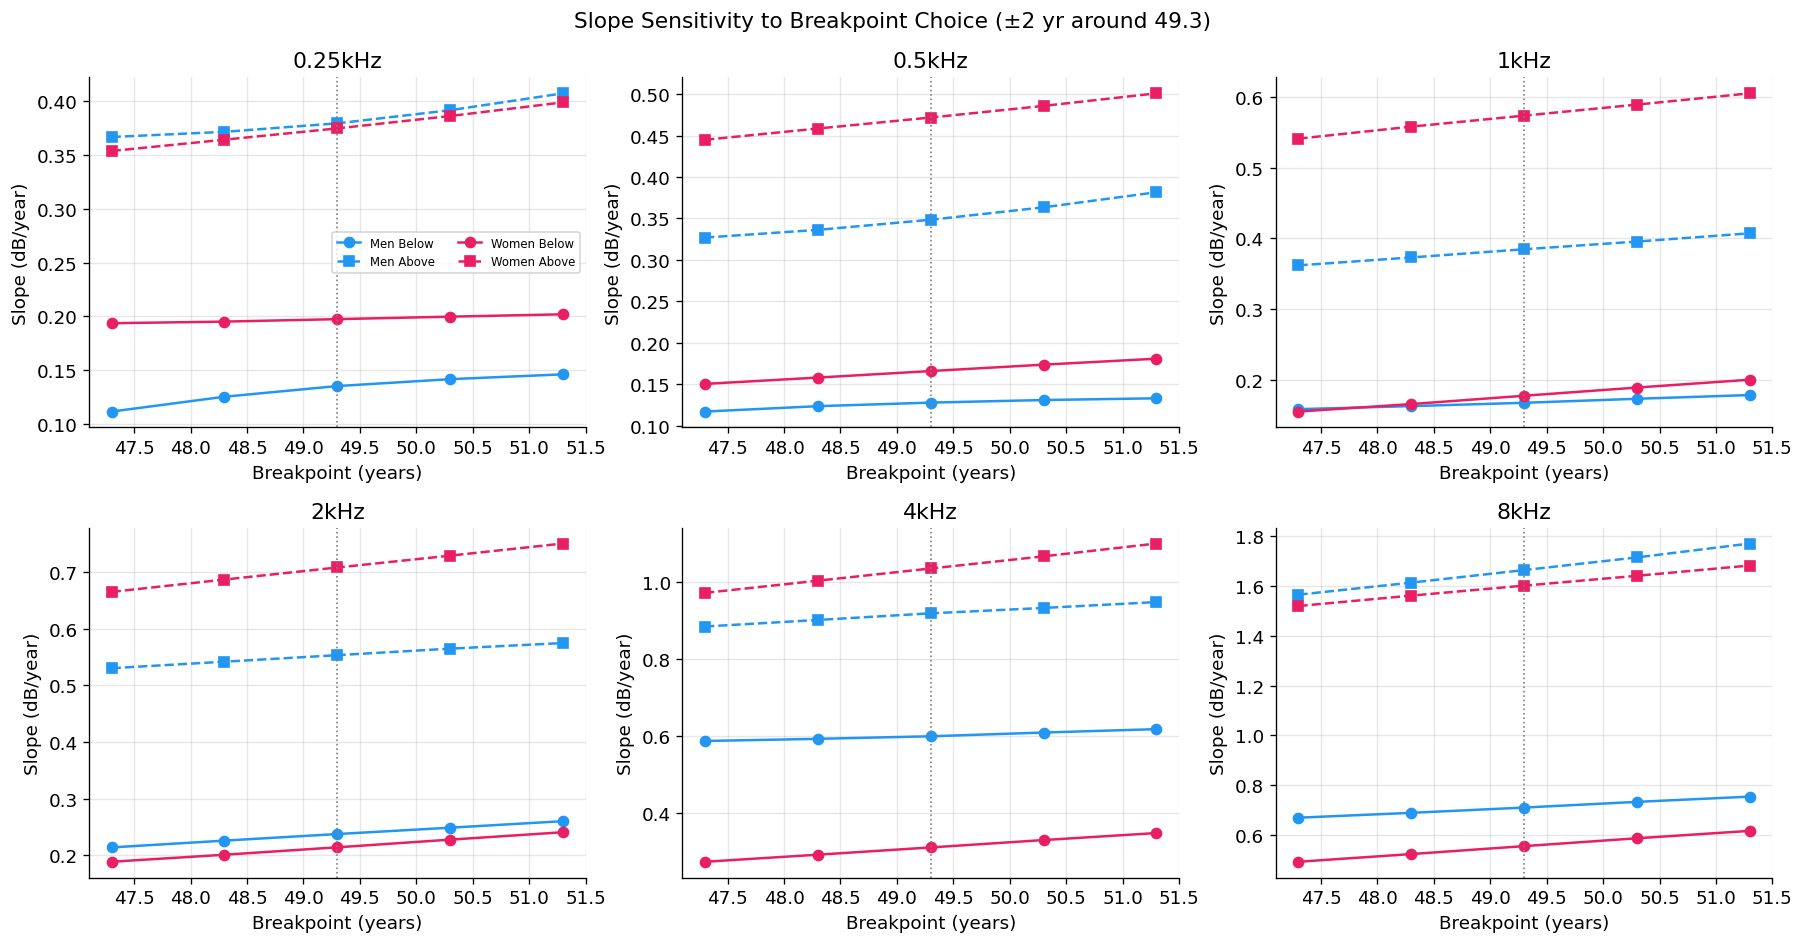

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, freq in zip(axes, FREQS):
    for sex in ['Men', 'Women']:
        sub_sens = sens_df[(sens_df['Sex'] == sex) & (sens_df['Freq'] == freq)]
        ax.plot(sub_sens['Breakpoint'], sub_sens['Slope_below'],
                marker='o', color=COLORS[sex], linestyle='-', label=f'{sex} Below')
        ax.plot(sub_sens['Breakpoint'], sub_sens['Slope_above'],
                marker='s', color=COLORS[sex], linestyle='--', label=f'{sex} Above')

    ax.axvline(BREAKPOINT, color='gray', linestyle=':', linewidth=1)
    ax.set_title(freq)
    ax.set_xlabel('Breakpoint (years)')
    ax.set_ylabel('Slope (dB/year)')
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7, ncol=2)
plt.suptitle('Slope Sensitivity to Breakpoint Choice (±2 yr around 49.3)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_sensitivity_breakpoints.png', bbox_inches='tight')
plt.show()

### 6.7 PSM Sensitivity — repeat main analysis on matched sample

In [33]:
ancova_matched = collect_ancova_pvalues(df_matched)
reject_m, p_fdr_m, _, _ = multipletests(ancova_matched['Raw p'], alpha=0.05, method='fdr_bh')
ancova_matched['FDR-adj p'] = p_fdr_m.round(4)
ancova_matched['Significant'] = reject_m

print('=== ANCOVA on PSM-Matched Sample ===')
print(ancova_matched.to_string(index=False))

=== ANCOVA on PSM-Matched Sample ===
AgeGroup    Freq  SexCoef (dB)  Raw p  FDR-adj p  Significant
  < 49.3 0.25kHz         0.860 0.0328     0.0492         True
  < 49.3  0.5kHz         0.290 0.4392     0.5270        False
  < 49.3    1kHz        -0.382 0.3219     0.4292        False
  < 49.3    2kHz        -1.282 0.0029     0.0058         True
  < 49.3    4kHz        -7.177 0.0000     0.0000         True
  < 49.3    8kHz        -6.704 0.0000     0.0000         True
  ≥ 49.3 0.25kHz         0.360 0.6118     0.6674        False
  ≥ 49.3  0.5kHz         1.789 0.0085     0.0146         True
  ≥ 49.3    1kHz         2.020 0.0025     0.0058         True
  ≥ 49.3    2kHz         0.166 0.8347     0.8347        False
  ≥ 49.3    4kHz        -8.331 0.0000     0.0000         True
  ≥ 49.3    8kHz        -6.652 0.0000     0.0000         True


### 6.8 Final summary table — all estimates side by side

In [34]:
summary_rows = []

for sex in ['Men', 'Women']:
    sub = df[df['SexLabel'] == sex]
    for freq in FREQS:
        bsr = bootstrap_results[(sex, freq)]
        _, d_ols = fit_piecewise_ols(sub, freq)
        m_rob, _ = fit_piecewise_robust(sub, freq)
        for seg, slope_key, ci_key, param in [
            ('< 49.3 yr', 'slope_below', 'CI_below', 'Age_below'),
            ('≥ 49.3 yr', 'slope_above', 'CI_above', 'Age_above'),
        ]:
            summary_rows.append({
                'Sex': sex,
                'Frequency': freq,
                'Age Segment': seg,
                'Slope (dB/yr)': round(bsr[slope_key], 3),
                '95% Boot CI': f"[{bsr[ci_key][0]:+.3f}, {bsr[ci_key][1]:+.3f}]",
                'Robust SE p': round(m_rob.pvalues[param], 4)
            })

summary_df = pd.DataFrame(summary_rows)
print('=== Final Summary: Piecewise Slopes with Bootstrap BCa CI ===')
print(summary_df.to_string(index=False))
summary_df.to_excel('final_summary_slopes.xlsx', index=False)
print('\nSaved: final_summary_slopes.xlsx')

=== Final Summary: Piecewise Slopes with Bootstrap BCa CI ===
  Sex Frequency Age Segment  Slope (dB/yr)      95% Boot CI  Robust SE p
  Men   0.25kHz   < 49.3 yr          0.135 [+0.066, +0.196]          0.0
  Men   0.25kHz   ≥ 49.3 yr          0.379 [+0.257, +0.517]          0.0
  Men    0.5kHz   < 49.3 yr          0.128 [+0.064, +0.188]          0.0
  Men    0.5kHz   ≥ 49.3 yr          0.348 [+0.234, +0.469]          0.0
  Men      1kHz   < 49.3 yr          0.167 [+0.105, +0.230]          0.0
  Men      1kHz   ≥ 49.3 yr          0.385 [+0.261, +0.524]          0.0
  Men      2kHz   < 49.3 yr          0.238 [+0.164, +0.317]          0.0
  Men      2kHz   ≥ 49.3 yr          0.553 [+0.426, +0.695]          0.0
  Men      4kHz   < 49.3 yr          0.600 [+0.454, +0.737]          0.0
  Men      4kHz   ≥ 49.3 yr          0.918 [+0.706, +1.128]          0.0
  Men      8kHz   < 49.3 yr          0.710 [+0.542, +0.860]          0.0
  Men      8kHz   ≥ 49.3 yr          1.664 [+1.442, +1.879]   

---
## Summary of Findings

Run all cells above in order, then review:

| Output file | Contents |
|---|---|
| `slope_comparison_OLS_WLS_Robust_Bootstrap.csv` | OLS / WLS / HC3 / Bootstrap slope estimates |
| `slope_sex_diff_test.csv` | Interaction test for sex differences in slopes (FDR-adjusted) |
| `sensitivity_breakpoints.csv` | Slope estimates across 5 alternative breakpoints |
| `final_summary_slopes.xlsx` | Master table: piecewise slopes + BCa CI + robust p-values |
| `fig_*.png` | All visualisation figures |

### Statistical approach checklist

- [x] Data integrity validated for both files (shape, columns, nulls, duplicates)
- [x] PSM performed to address sex-group imbalance (sensitivity analysis)
- [x] Normality tested (Shapiro-Wilk / KS)
- [x] Heteroscedasticity tested (Breusch-Pagan) and visualised
- [x] Outliers identified (Cook's D)
- [x] WLS applied as primary remedy for heteroscedasticity
- [x] HC3 robust SEs applied as secondary remedy
- [x] Bootstrap BCa CIs for all slope estimates
- [x] FDR correction (BH) across all significance tests
- [x] Piecewise LR at fixed breakpoint 49.3 yr (Korean mean menopause age)
- [x] Dummy-variable interaction test for slope sex differences
- [x] Sensitivity analysis across breakpoints ±2 yr